# CNN Development on Satellite image classification Dataset
This notebook presents a complete PyTorch-based Convolutional Neural Network (CNN) pipeline for multi-class image classification using a custom scene image dataset. The workflow includes dataset loading, preprocessing, model design, training, evaluation, visualization, regularization comparison, and saving trained model weights.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -o "/content/drive/MyDrive/CVPR/Satellite.zip" -d /content/dataset

In [ ]:
!pip install torchinfo -q

## 1. Import Libraries
In this section, the required Python libraries are imported for data loading, preprocessing, model building, training, evaluation, and visualization. PyTorch is used for deep learning implementation, torchvision is used for dataset handling and image transforms, and scikit-learn is used for performance metrics such as precision, recall, F1-score, and confusion matrix.

In [ ]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    accuracy_score
)
from torchinfo import summary

In [ ]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/images
/content/dataset/data
/content/dataset/data/cloudy
/content/dataset/data/green_area
/content/dataset/data/water
/content/dataset/data/desert


## Configuration and Hyperparameters
This section defines the main experiment settings, including dataset path, batch size, number of epochs, learning rate, weight decay, random seed, and model save paths. These values control how the CNN is trained and evaluated.

In [ ]:
data_dir = "/content/dataset/data"
STUDENT_ID = "22-49015-3"
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

MODEL_SIMPLE_PATH = f"satellite_cnn_simple_{STUDENT_ID}.pth"
MODEL_REG_PATH = f"satellite_cnn_regularized_{STUDENT_ID}.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

Using device: cuda


## Data Preprocessing and Augmentation
Training images were preprocessed by resizing them to a fixed size and applying augmentation techniques such as random horizontal flipping and random rotation. These augmentations increase data variability and help the model generalize better. For validation images, only resizing and normalization were applied so that evaluation remains fair and consistent.


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


##  Hyperparameter Details and Rationale
The following hyperparameters were used in this experiment:

- Image size: 128 × 128  
  Images were resized to 128 × 128 so that the model receives a fixed input size while still preserving enough visual information.

- Batch size: 32  
  A batch size of 32 was selected because it provides stable gradient updates and works efficiently with available GPU memory.

- Number of epochs: 8  
  A moderate number of epochs was used to allow learning without making the training unnecessarily long.

- Learning rate: 0.001  
  This is a standard and effective starting learning rate for the Adam optimizer.

- Weight decay: 1e-4  
  Weight decay was used to reduce overfitting and improve model generalization.

- Optimizer: Adam  
  Adam was selected because it usually converges faster and performs well in image classification tasks.

- Loss function: CrossEntropyLoss  
  Cross-entropy loss is suitable for multi-class classification problems.

- Scheduler: StepLR  
  A learning rate scheduler was used to gradually reduce the learning rate during training, helping the model converge better.

- Batch Normalization and Dropout  
  These were included in the regularized model to stabilize training and reduce overfitting.


In [ ]:
data_dir = "/content/dataset/data"

#Load dataset
full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(data_dir, transform=eval_transform)

#Split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_indices, val_indices = random_split(
    range(len(full_train_dataset)),
    [train_size, val_size],
    generator=generator
)

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices.indices)
val_dataset = torch.utils.data.Subset(full_val_dataset, val_indices.indices)

#Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

#Info
class_names = full_train_dataset.classes

print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Classes: ['cloudy', 'desert', 'green_area', 'water']
Train size: 4504
Val size: 1127


## Load and Explore Dataset

The dataset was loaded using PyTorch ImageFolder, where each folder represents one class. The dataset contains four classes: cloudy, desert, green_area, and water. The data was split into training and validation subsets, and data loaders were created for efficient batch processing during training and evaluation.
### Visual Inspection of Sample Images
A few sample images from the training set are displayed in this section to verify that the dataset has been loaded correctly. This also helps confirm that the class labels are properly assigned and that the images are visually suitable for classification.


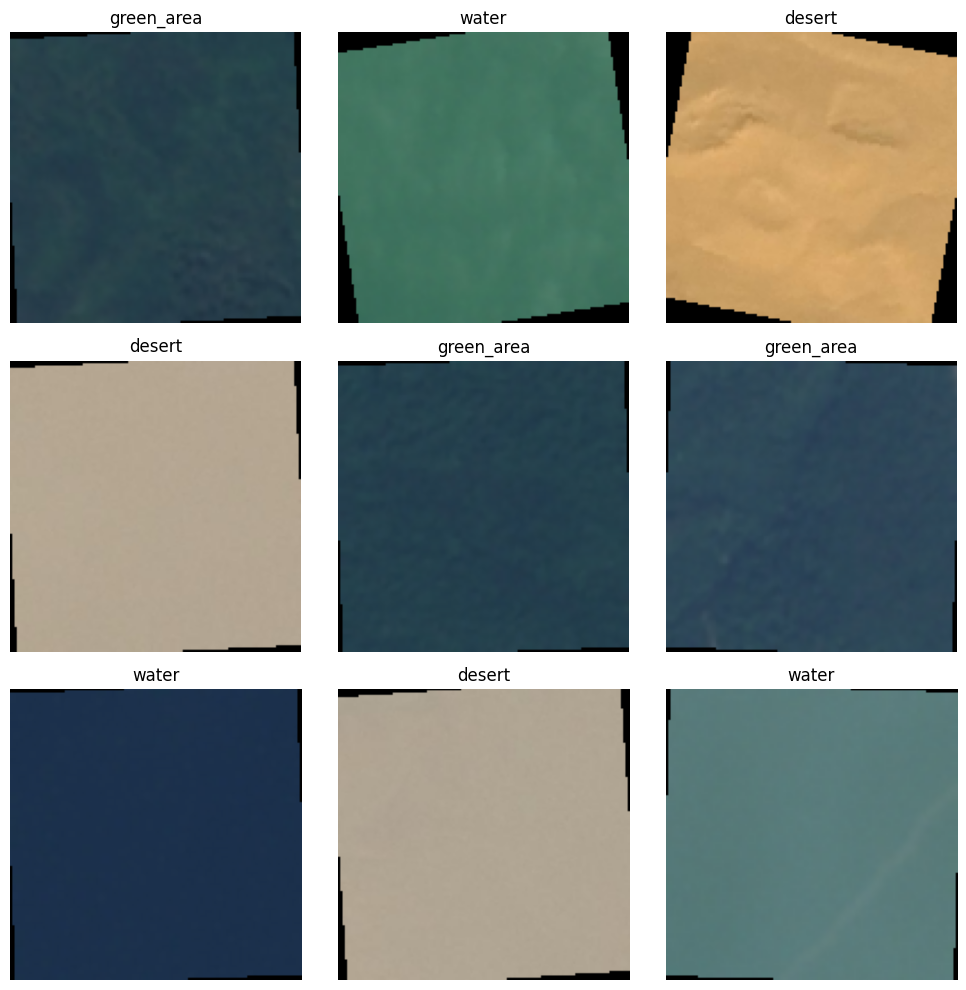

In [ ]:
def show_images(loader, class_names):
    images, labels = next(iter(loader))
    images = images[:9]
    labels = labels[:9]

    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_loader, class_names)

##  Define CNN Architecture

A custom CNN architecture was designed for this task. The network consists of three convolutional layers followed by ReLU activation and max-pooling operations. After feature extraction, fully connected layers are used for classification. Two versions of the model were considered: a simple CNN without regularization, and a regularized CNN with batch normalization and dropout.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes, use_bn=False, use_dropout=False, dropout_rate=0.5):
        super(CustomCNN, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        if self.use_bn:
            x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)
        return x

In [ ]:
num_classes = len(class_names)

##  Model Summary

The architecture summary is shown in this section to verify the structure of the model, including the layer arrangement, parameter count, and input-output dimensions. This helps ensure that the network is correctly built before training begins.

In [ ]:
model_simple = CustomCNN(num_classes=num_classes, use_bn=False, use_dropout=False).to(device)
print("Simple CNN Summary:")
summary(model_simple, input_size=(32, 3, 128, 128))

model_regularized = CustomCNN(num_classes=num_classes, use_bn=True, use_dropout=True).to(device)
print("\nRegularized CNN Summary:")
summary(model_regularized, input_size=(32, 3, 128, 128))

Simple CNN Summary:

Regularized CNN Summary:


Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [32, 4]                   --
├─Conv2d: 1-1                            [32, 32, 128, 128]        896
├─BatchNorm2d: 1-2                       [32, 32, 128, 128]        64
├─ReLU: 1-3                              [32, 32, 128, 128]        --
├─MaxPool2d: 1-4                         [32, 32, 64, 64]          --
├─Conv2d: 1-5                            [32, 64, 64, 64]          18,496
├─BatchNorm2d: 1-6                       [32, 64, 64, 64]          128
├─ReLU: 1-7                              [32, 64, 64, 64]          --
├─MaxPool2d: 1-8                         [32, 64, 32, 32]          --
├─Conv2d: 1-9                            [32, 128, 32, 32]         73,856
├─BatchNorm2d: 1-10                      [32, 128, 32, 32]         256
├─ReLU: 1-11                             [32, 128, 32, 32]         --
├─MaxPool2d: 1-12                        [32, 128, 16, 16]         --
├─Li

## Training and Validation Functions

Reusable functions were defined for training and validation to keep the notebook organized and readable. These functions compute loss and accuracy for each epoch and allow the model to be trained in a structured way.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
def train_model(model, train_loader, val_loader, epochs=8, lr=0.001, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

## Train Simple CNN

In this experiment, a baseline CNN model without batch normalization and dropout was trained. This model provides a reference point for comparing the effect of regularization techniques on performance.

In [ ]:
model_simple = CustomCNN(num_classes=num_classes, use_bn=False, use_dropout=False).to(device)
model_simple, history_simple = train_model(
    model_simple,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

Epoch 1/8 | Train Loss: 0.4662 | Train Acc: 0.7613 | Val Loss: 0.3960 | Val Acc: 0.8447
Epoch 2/8 | Train Loss: 0.3006 | Train Acc: 0.8768 | Val Loss: 0.2455 | Val Acc: 0.8935
Epoch 3/8 | Train Loss: 0.2591 | Train Acc: 0.8932 | Val Loss: 0.2459 | Val Acc: 0.9086
Epoch 4/8 | Train Loss: 0.2328 | Train Acc: 0.9076 | Val Loss: 0.1954 | Val Acc: 0.9219
Epoch 5/8 | Train Loss: 0.2049 | Train Acc: 0.9187 | Val Loss: 0.2203 | Val Acc: 0.9210
Epoch 6/8 | Train Loss: 0.1999 | Train Acc: 0.9194 | Val Loss: 0.1748 | Val Acc: 0.9308
Epoch 7/8 | Train Loss: 0.1626 | Train Acc: 0.9341 | Val Loss: 0.1479 | Val Acc: 0.9503
Epoch 8/8 | Train Loss: 0.1600 | Train Acc: 0.9336 | Val Loss: 0.1630 | Val Acc: 0.9255

Training completed in 1.75 minutes
Best validation accuracy: 0.9503


##  Train Regularized CNN

In this experiment, a regularized CNN model with batch normalization and dropout was trained. Batch normalization helps stabilize learning, while dropout helps reduce overfitting by randomly disabling some neurons during training.

In [ ]:
model_regularized = CustomCNN(num_classes=num_classes, use_bn=True, use_dropout=True).to(device)
model_regularized, history_regularized = train_model(
    model_regularized,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

Epoch 1/8 | Train Loss: 0.8191 | Train Acc: 0.7822 | Val Loss: 0.5090 | Val Acc: 0.8137
Epoch 2/8 | Train Loss: 0.3995 | Train Acc: 0.8355 | Val Loss: 0.2903 | Val Acc: 0.8962
Epoch 3/8 | Train Loss: 0.3961 | Train Acc: 0.8413 | Val Loss: 0.3891 | Val Acc: 0.7941
Epoch 4/8 | Train Loss: 0.3101 | Train Acc: 0.8763 | Val Loss: 0.2137 | Val Acc: 0.9175
Epoch 5/8 | Train Loss: 0.2920 | Train Acc: 0.8770 | Val Loss: 0.2354 | Val Acc: 0.9051
Epoch 6/8 | Train Loss: 0.2990 | Train Acc: 0.8837 | Val Loss: 0.1801 | Val Acc: 0.9299
Epoch 7/8 | Train Loss: 0.2628 | Train Acc: 0.8970 | Val Loss: 0.1701 | Val Acc: 0.9406
Epoch 8/8 | Train Loss: 0.2369 | Train Acc: 0.9001 | Val Loss: 0.1815 | Val Acc: 0.9130

Training completed in 1.82 minutes
Best validation accuracy: 0.9406


##  Training Curves

Training and validation loss and accuracy curves are plotted to analyze the learning behavior of the model across epochs. These visualizations are useful for identifying whether the model is improving steadily and whether there is any sign of overfitting or underfitting.

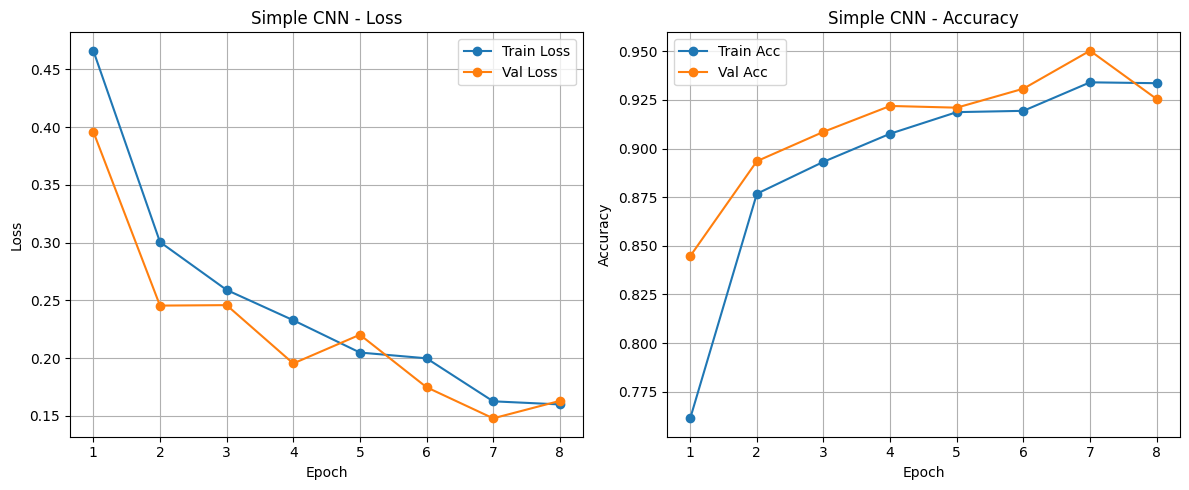

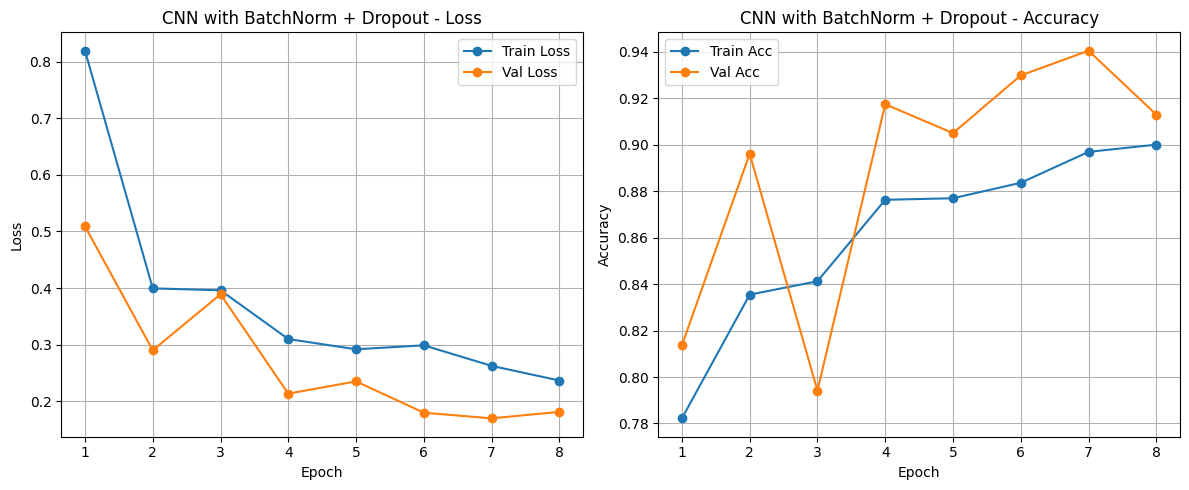

In [ ]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker='o', label="Train Acc")
    plt.plot(epochs, history["val_acc"], marker='o', label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_simple, "Simple CNN")
plot_history(history_regularized, "CNN with BatchNorm + Dropout")

## Model Evaluation

The trained model was evaluated using validation data. Performance was measured using accuracy, precision, recall, and F1-score. These metrics provide a more complete understanding of the model’s classification quality than accuracy alone.

In [ ]:
def evaluate_model(model, loader, class_names, model_name="Model"):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    print(f"\n===== {model_name} Test Results =====")
    print("Test Accuracy:", round(acc, 4))
    print("Weighted Precision:", round(precision, 4))
    print("Weighted Recall:", round(recall, 4))
    print("Weighted F1-score:", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return all_labels, all_preds

## Per-Class Performance Analysis

Class-wise precision, recall, and F1-score were analyzed in this section. The best and worst performing classes were identified based on F1-score. This analysis helps understand where the model performs strongly and where improvement may still be needed.

In [ ]:
def class_performance(all_labels, all_preds, class_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )

    results = []
    for i, class_name in enumerate(class_names):
        results.append({
            "class": class_name,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i]
        })

    results = sorted(results, key=lambda x: x["f1"], reverse=True)

    print("Best performing class:")
    print(results[0])

    print("\nWorst performing class:")
    print(results[-1])

    print("\nAll class-wise results:")
    for r in results:
        print(r)

    return results

##  Confusion Matrix

A confusion matrix was generated to visualize how well the model predicted each class. It shows the number of correct and incorrect predictions for every class, helping identify which categories are easier or harder for the model.


===== Simple CNN Test Results =====
Test Accuracy: 0.9503
Weighted Precision: 0.9509
Weighted Recall: 0.9503
Weighted F1-score: 0.9502

Classification Report:

              precision    recall  f1-score   support

      cloudy       0.96      0.97      0.97       299
      desert       0.97      0.96      0.97       243
  green_area       0.92      0.96      0.94       303
       water       0.96      0.90      0.93       282

    accuracy                           0.95      1127
   macro avg       0.95      0.95      0.95      1127
weighted avg       0.95      0.95      0.95      1127



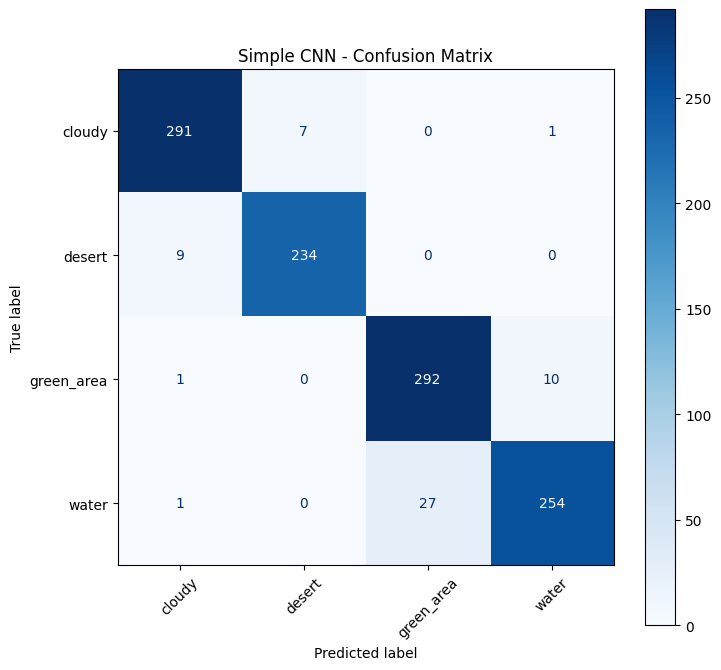

Best performing class:
{'class': 'cloudy', 'precision': np.float64(0.9635761589403974), 'recall': np.float64(0.9732441471571907), 'f1': np.float64(0.9683860232945092), 'support': np.int64(299)}

Worst performing class:
{'class': 'water', 'precision': np.float64(0.9584905660377359), 'recall': np.float64(0.900709219858156), 'f1': np.float64(0.9287020109689214), 'support': np.int64(282)}

All class-wise results:
{'class': 'cloudy', 'precision': np.float64(0.9635761589403974), 'recall': np.float64(0.9732441471571907), 'f1': np.float64(0.9683860232945092), 'support': np.int64(299)}
{'class': 'desert', 'precision': np.float64(0.970954356846473), 'recall': np.float64(0.9629629629629629), 'f1': np.float64(0.9669421487603306), 'support': np.int64(243)}
{'class': 'green_area', 'precision': np.float64(0.9153605015673981), 'recall': np.float64(0.9636963696369637), 'f1': np.float64(0.9389067524115756), 'support': np.int64(303)}
{'class': 'water', 'precision': np.float64(0.9584905660377359), 'recall

In [ ]:
labels_simple, preds_simple = evaluate_model(
    model_simple,
    val_loader,
    class_names,
    model_name="Simple CNN"
)

results_simple = class_performance(labels_simple, preds_simple, class_names)


===== Regularized CNN Test Results =====
Test Accuracy: 0.9406
Weighted Precision: 0.9408
Weighted Recall: 0.9406
Weighted F1-score: 0.9405

Classification Report:

              precision    recall  f1-score   support

      cloudy       0.94      0.96      0.95       299
      desert       0.95      0.94      0.95       243
  green_area       0.92      0.95      0.94       303
       water       0.95      0.91      0.93       282

    accuracy                           0.94      1127
   macro avg       0.94      0.94      0.94      1127
weighted avg       0.94      0.94      0.94      1127



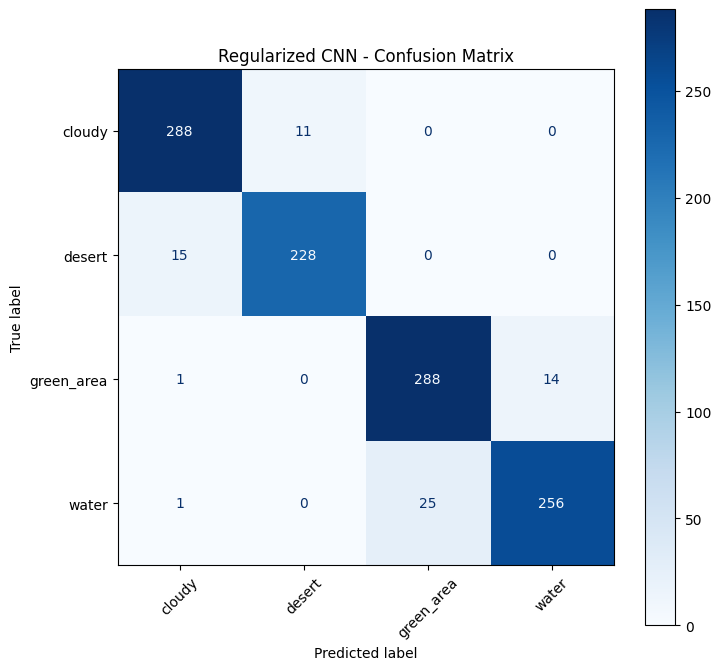

Best performing class:
{'class': 'cloudy', 'precision': np.float64(0.9442622950819672), 'recall': np.float64(0.9632107023411371), 'f1': np.float64(0.9536423841059603), 'support': np.int64(299)}

Worst performing class:
{'class': 'water', 'precision': np.float64(0.9481481481481482), 'recall': np.float64(0.9078014184397163), 'f1': np.float64(0.927536231884058), 'support': np.int64(282)}

All class-wise results:
{'class': 'cloudy', 'precision': np.float64(0.9442622950819672), 'recall': np.float64(0.9632107023411371), 'f1': np.float64(0.9536423841059603), 'support': np.int64(299)}
{'class': 'desert', 'precision': np.float64(0.9539748953974896), 'recall': np.float64(0.9382716049382716), 'f1': np.float64(0.946058091286307), 'support': np.int64(243)}
{'class': 'green_area', 'precision': np.float64(0.9201277955271565), 'recall': np.float64(0.9504950495049505), 'f1': np.float64(0.935064935064935), 'support': np.int64(303)}
{'class': 'water', 'precision': np.float64(0.9481481481481482), 'recall'

In [ ]:
labels_reg, preds_reg = evaluate_model(
    model_regularized,
    val_loader,
    class_names,
    model_name="Regularized CNN"
)

results_reg = class_performance(labels_reg, preds_reg, class_names)

##  Save Trained Model

The trained model weights were saved in `.pth` format so that the model can be reused later for inference, testing, or further training. Saving model weights is also one of the required deliverables of the assignment.

In [ ]:

torch.save(model_simple.state_dict(), MODEL_SIMPLE_PATH)
torch.save(model_regularized.state_dict(), MODEL_REG_PATH)

print("Models saved successfully:")
print(MODEL_SIMPLE_PATH)
print(MODEL_REG_PATH)

Models saved successfully:
satellite_cnn_simple_22-49015-3.pth
satellite_cnn_regularized_22-49015-3.pth


In [ ]:
from google.colab import files

files.download(MODEL_SIMPLE_PATH)
files.download(MODEL_REG_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Comparison of Simple and Regularized Models

The simple CNN and the regularized CNN were compared based on validation performance. The regularized model is expected to generalize better because batch normalization improves training stability and dropout reduces overfitting. Comparing both models makes the analysis more complete and directly addresses the assignment requirement.

In [ ]:

print("Simple model best class:", results_simple[0])
print("Simple model worst class:", results_simple[-1])

print("\nRegularized model best class:", results_reg[0])
print("Regularized model worst class:", results_reg[-1])

Simple model best class: {'class': 'cloudy', 'precision': np.float64(0.9635761589403974), 'recall': np.float64(0.9732441471571907), 'f1': np.float64(0.9683860232945092), 'support': np.int64(299)}
Simple model worst class: {'class': 'water', 'precision': np.float64(0.9584905660377359), 'recall': np.float64(0.900709219858156), 'f1': np.float64(0.9287020109689214), 'support': np.int64(282)}

Regularized model best class: {'class': 'cloudy', 'precision': np.float64(0.9442622950819672), 'recall': np.float64(0.9632107023411371), 'f1': np.float64(0.9536423841059603), 'support': np.int64(299)}
Regularized model worst class: {'class': 'water', 'precision': np.float64(0.9481481481481482), 'recall': np.float64(0.9078014184397163), 'f1': np.float64(0.927536231884058), 'support': np.int64(282)}


##  Analysis and Discussion of Results

The results show how effectively the CNN learned to classify the four scene categories. Classes with more distinct visual patterns are expected to achieve better scores, while visually similar classes may be harder to separate. The confusion matrix and class-wise metrics provide useful insight into these differences. Regularization can improve generalization by making the model less sensitive to noise and overfitting.

## Conclusion and Future Work

This notebook presented a complete PyTorch-based CNN pipeline for multi-class scene classification using a custom dataset. The workflow included preprocessing, data loading, custom CNN design, training, evaluation, visualization, confusion matrix analysis, per-class performance analysis, and saving model weights.

Future improvements may include training for more epochs, applying stronger data augmentation, testing deeper architectures, using transfer learning, and collecting more balanced data for each class.